In [31]:
import sys
sys.path.insert(0, "/Users/jkingslake/Documents/science/meltwater_routing/fsm_pywrapper/fillspillmerge")
sys.path.insert(0, "../scripts")

from fillspillmerge import fill_spill_merge
import pdemtools as pdt
import rioxarray
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from funcs import fsm, cellArea
import xrspatial


## Load a DEM

In [84]:
d = rioxarray.open_rasterio('Nivlisen_32m_REMA.tif').squeeze()
coarsen_factor = 1
d = d.coarsen(x=coarsen_factor, y=coarsen_factor, boundary='trim').mean()
ocean_value = 0.0



x1 = d.x.mean().values
y1 = d.y.mean().values

d = d.sel(x=slice(x1, x1 + 20000), y=slice(y1, y1 - 20000))

d[0:1,:] = ocean_value 
d[-1:,:] = ocean_value
d[:,0:1] = ocean_value
d[:,-1:] = ocean_value

_, hier = fill_spill_merge(
    topography=d,
    ocean_level=ocean_value,
    return_hierarchy=True,
)

## Optionally coarsen the DEM

In [85]:
coarsen_factor = 1
d = d.coarsen(x=coarsen_factor, y=coarsen_factor, boundary='trim').mean()


## Add ocean around the edge of the DEM

In [86]:
ocean_value = 0.0

d[0:1,:] = ocean_value 
d[-1:,:] = ocean_value
d[:,0:1] = ocean_value
d[:,-1:] = ocean_value

In [87]:
m = d*0+0.01


In [88]:
_, dh = fill_spill_merge(
    topography=d,
    ocean_level=0.0,
    return_hierarchy=True,
)



In [89]:
ds = fsm(d, m, dh=dh)

In [90]:
ds

<xarray.Dataset> Size: 13MB
Dimensions:                       (x: 625, y: 625)
Coordinates:
  * x                             (x) float64 5kB 4.37e+05 4.37e+05 ... 4.57e+05
  * y                             (y) float64 5kB 2.079e+06 ... 2.059e+06
    spatial_ref                   int64 8B 0
Data variables: (12/16)
    water_depth                   (y, x) float64 3MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    melt                          (y, x) float32 2MB 0.01 0.01 ... 0.01 0.01
    dem                           (y, x) float32 2MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    x_com_w                       float64 8B 4.45e+05
    y_com_w                       float64 8B 2.07e+06
    x_com_m                       float64 8B 4.47e+05
    ...                            ...
    accumulation_on_grounded_ice  float64 8B 1.968e+06
    melt_on_grounded_ice          float64 8B 3.27e+06
    water_flow_over_GL            float64 8B 1.302e+06
    grounded_mask                 (y, x) int64 3MB 0 0 0 0 0 0 0 ... 1 1 1 1 1 1
    accumulation_total            float64 8B 2.63e+06
    melt_total                    float64 8B 4e+06
Attributes:
    fillspillmerge_ocean_level:            0.0
    fillspillmerge_used_cached_hierarchy:  True
    long_name:                             water depth
    units:                                 m

In [91]:
from xrspatial.geotiff import open_geotiff, to_geotiff

In [92]:
to_geotiff(d, 'xspatial_dem.tif')

'xspatial_dem.tif'

In [93]:
# xspatial_dem = open_geotiff('xspatial_dem.tif')
# type(xspatial_dem)

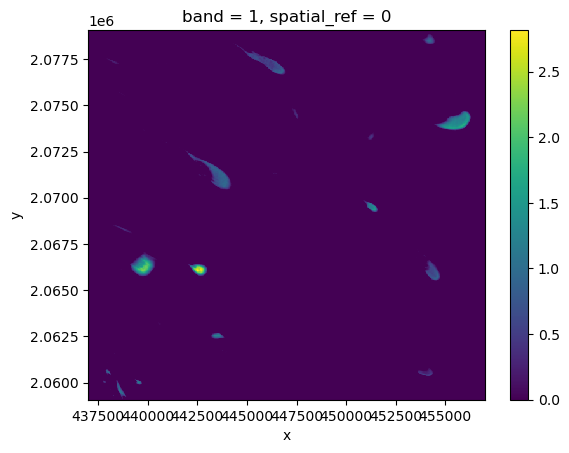

In [100]:
d_filled = xrspatial.hydro.fill(d)
lakes = (d_filled-d)
lakes.plot()

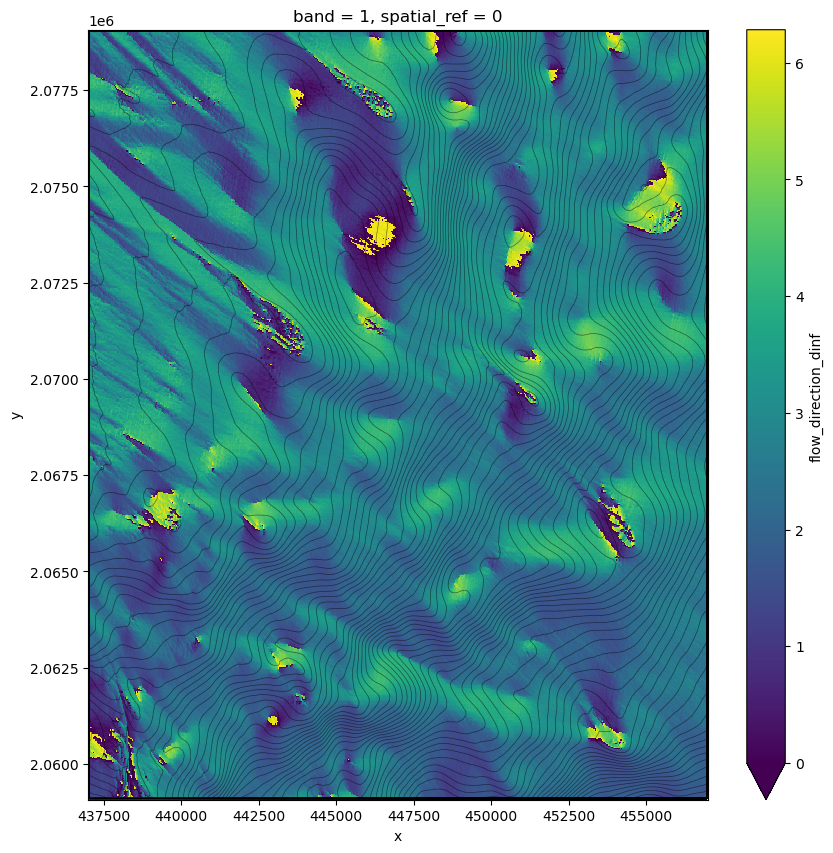

In [133]:

fdir = xrspatial.flow_direction(d, routing='dinf')
acc = xrspatial.flow_accumulation(fdir, routing='dinf')

fdir.plot(figsize=(10, 10), vmin = 0, vmax = np.pi*2)
d.plot.contour( levels = 100, linewidths = 0.5, colors = 'k', alpha = 0.5)


(array([   239.,   6355.,  21574.,  60991., 115609., 103759.,  59171.,
         13809.,   3803.,   2819.]),
 array([-1.        , -0.2716837 ,  0.45663259,  1.18494889,  1.91326518,
         2.64158148,  3.36989778,  4.09821407,  4.82653037,  5.55484666,
         6.28316296]),
 <BarContainer object of 10 artists>)

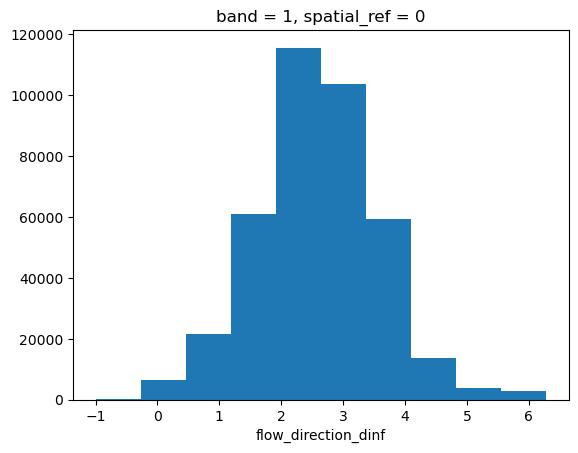

In [132]:
fdir.plot.hist()

In [ ]:
fdir.plot()

In [127]:
acc.drop_vars(['band'])

<xarray.DataArray 'flow_accumulation' (y: 625, x: 625)> Size: 3MB
array([[         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,   1.        ,   1.        , ...,   1.        ,
          1.        ,          nan],
       [         nan, 106.18812828,   8.28865114, ...,   1.        ,
          1.        ,          nan],
       ...,
       [         nan,   1.        ,   1.        , ...,   1.        ,
          1.        ,          nan],
       [         nan,   1.        ,   1.        , ...,   1.        ,
          1.        ,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan]], shape=(625, 625))
Coordinates:
  * x            (x) float64 5kB 4.37e+05 4.37e+05 ... 4.569e+05 4.57e+05
  * y            (y) float64 5kB 2.079e+06 2.079e+06 ... 2.059e+06 2.059e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -9999.0
    scale_factor:   1.0
    add_offset:     0.0

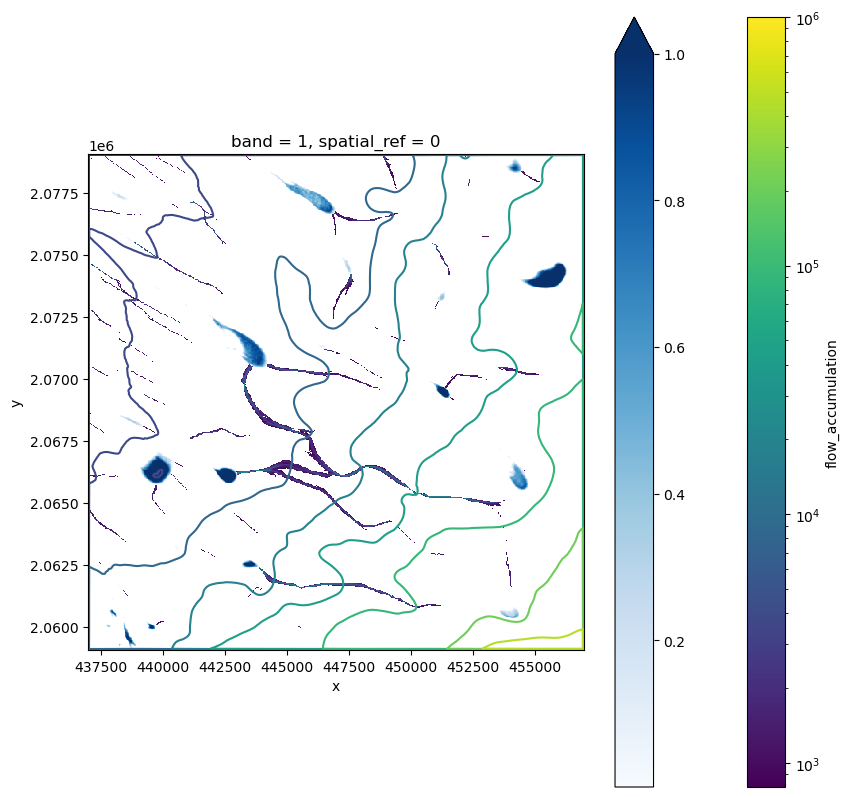

In [125]:
acc = xrspatial.flow_accumulation(fdir, routing='dinf')

d.plot.contour(figsize=(10, 10), levels = 10)
acc.where(acc > 800).plot(vmax=1e6, norm=plt.matplotlib.colors.LogNorm())
lakes.where(lakes > 0).plot(cmap='Blues', vmax = 1)
plt.gca().set_aspect('equal')

In [105]:
basins = xrspatial.hydro.basin_d8(fdir)

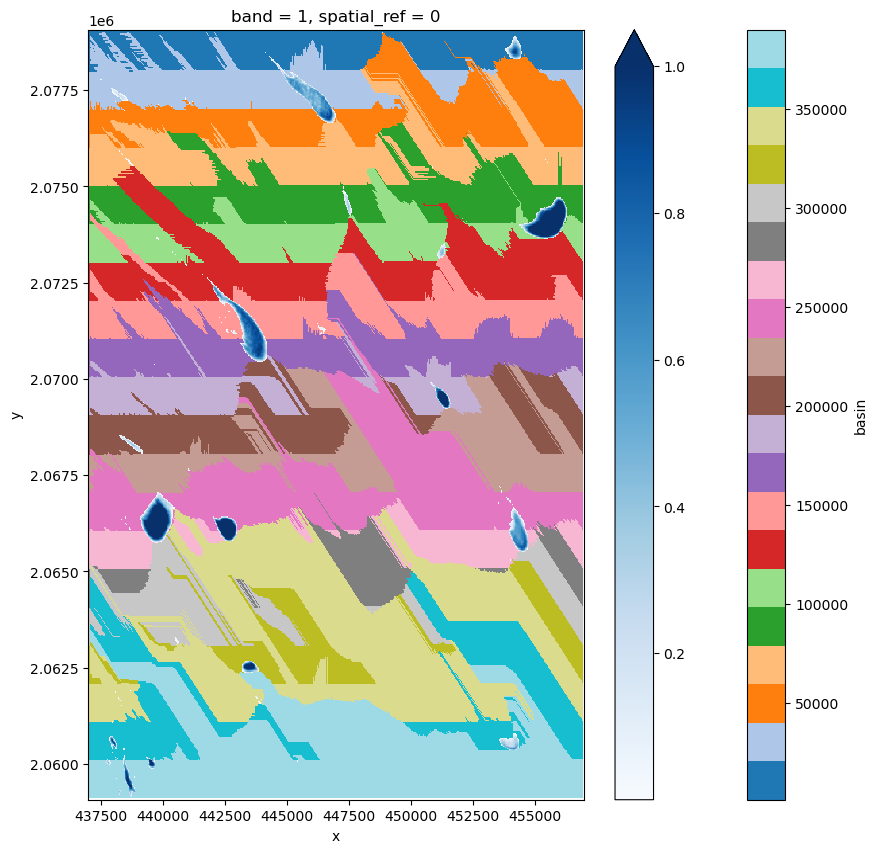

In [108]:
basins.plot(cmap='tab20', figsize=(10, 10))
lakes.where(lakes > 0).plot(cmap='Blues', vmax = 1)


In [111]:
stream_link = xrspatial.stream_link(fdir, acc, threshold=800)

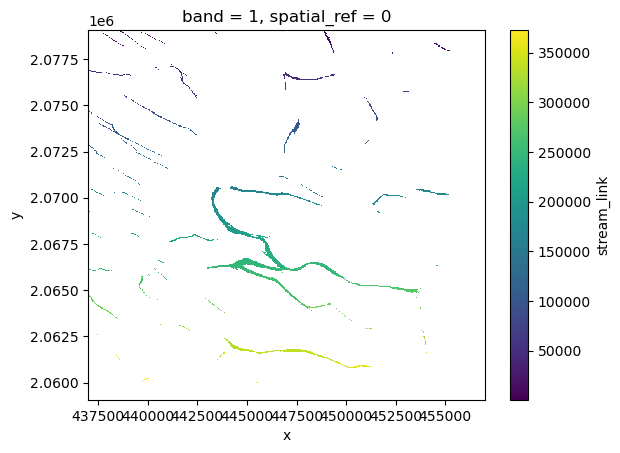

In [112]:
stream_link.plot()

In [113]:
stream_order = xrspatial.stream_order(fdir, acc, threshold=800)

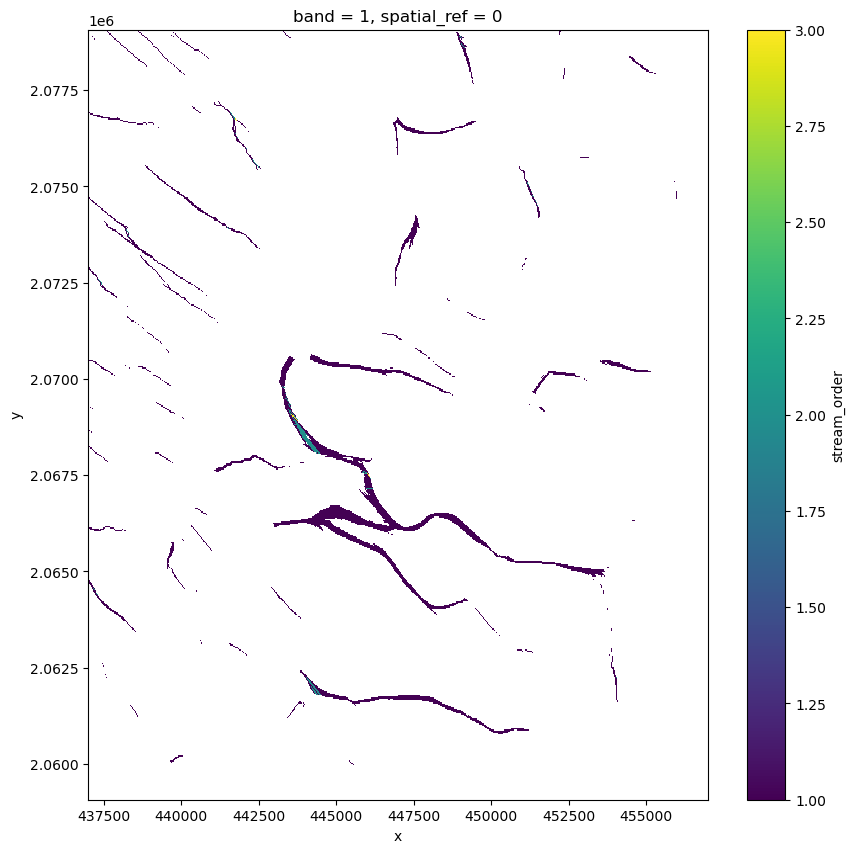

In [116]:
stream_order.plot(figsize=(10, 10))